In [1]:
import os
import sys
import re
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import pandas as pd
from scipy.interpolate import Akima1DInterpolator
from PIL import Image
from glob import glob
from tools.fdm.src import fdm3Blom, mfgrid
from tools.etc import color_cycler, logo, descr, pickleto, picklefrom

NOTEBOOK_NAME = "explore_data.ipynb"
print(f"NOTEBOOK_NAME = '{NOTEBOOK_NAME}'")

# --- project directory namespace
class Dirs:
    def __init__(self):
        self.rws = "/Users/Theo/Development/python/mf6_tools/mf6lab/Projects/ARK_RWS/"
        self.home   = os.path.join(self.rws, "src")
        self.images = os.path.normpath(os.path.join(self.home, '../images'))
        self.data   = os.path.normpath(os.path.join(self.home, '../data'))
        self.pb_data = os.path.normpath(os.path.join(self.data, 'peilbuizen'))
        self.pb_imag = os.path.normpath(os.path.join(self.images, 'peilbuizen'))
        
dirs = Dirs()

# --- dtypes for boundary conditions of Fdm3
dtypes = fdm3Blom.Fdm3.dtypes

print("Project directory namespace:")
descr(dirs)

loading mfpath.py
NOTEBOOK_NAME = 'explore_data.ipynb'
Project directory namespace:
rws                  /Users/Theo/Development/python/mf6_tools/mf6lab/Projects/ARK_RWS/
home                 /Users/Theo/Development/python/mf6_tools/mf6lab/Projects/ARK_RWS/src
images               /Users/Theo/Development/python/mf6_tools/mf6lab/Projects/ARK_RWS/images
data                 /Users/Theo/Development/python/mf6_tools/mf6lab/Projects/ARK_RWS/data
pb_data              /Users/Theo/Development/python/mf6_tools/mf6lab/Projects/ARK_RWS/data/peilbuizen
pb_imag              /Users/Theo/Development/python/mf6_tools/mf6lab/Projects/ARK_RWS/images/peilbuizen


In [2]:
class Peilbuizen():
    def __init__(self, workbook_name, sheet_name=None):
        self.data = pd.read_excel(os.path.join(dirs.pb_imag, workbook_name), sheet_name=sheet_name, index_col='name')
        
    def plot(self, ax, **kwargs):
        """Plot all observation well locations at once."""
        ax.plot(self.data['x'], self.data['y'], 'o', **kwargs)
        
    def put_raai_names(self, ax, xoffset=100., verbose=False, **kwargs):
        """Put the piezometer row names to the right of the last in the row + xoffset."""
        rows = np.arange(100, 1500, 100)
        for r1, r2 in zip(rows[:-1], rows[1:]):
            y = pbxy.data.loc[np.logical_and(pbxy.data.index >= r1, pbxy.data.index < r2), 'y'].mean().round()
            x = pbxy.data.loc[np.logical_and(pbxy.data.index >= r1, pbxy.data.index < r2), 'x'].values[-1].round() + xoffset
            ax.text(x, y, f'raai{r1/100:.0f}', **kwargs)
            if verbose:
                print(f"raai{r1/100:.0f}, x={x:.0f}, y={y:.0f}") 


# --- Example:
pbxy = Peilbuizen(os.path.join(dirs.pb_imag, 'pb_tauw_XY.xlsx'), sheet_name='pbTauw')

# --- Plot the data (could be on a map).
# fig, ax = plt.subplots(figsize=(8, 12))
# pbxy.plot(ax, mec='r', mfc='none', ms=6)
# pbxy.put_raai_names(ax, ha='left', va='center')
# ax.plot(ARK_center_line_GE[:,0], ARK_center_line_GE[:,1], 'b', label='ARK-hartlijn')
# ax.set_aspect(1)
# 
# plt.show()


In [3]:
def point_line_distance(P, A, B):
    """
    Distance from points P to infinite line through A and B.

    Parameters
    ----------
    P : (..., 2) array_like
        One or more points.
    A, B : (2,) array_like
        Two points defining the line.

    Returns
    -------
    d : ndarray
        Distances.
    """

    P = np.asarray(P)
    A = np.asarray(A)
    B = np.asarray(B)

    AB = B - A
    AP = P - A

    cross = AB[0] * AP[..., 1] - AB[1] * AP[..., 0]

    return np.round(np.abs(cross) / np.linalg.norm(AB), 2), np.sign(cross)




def point_segment_distance(P, A, B):
    P = np.asarray(P)
    A = np.asarray(A)
    B = np.asarray(B)

    AB = B - A
    AP = P - A

    L2 = np.dot(AB, AB)

    t = np.sum(AP * AB, axis=-1) / L2
    t = np.clip(t, 0.0, 1.0)

    Q = A + t[..., None] * AB

    return np.linalg.norm(P - Q, axis=-1)


def point_polyline_distance(P, polyline):
    """
    Distance from points P to a polyline.

    Parameters
    ----------
    P : (..., 2) array
        One or more points.
    polyline : (n, 2) array
        Vertices of the polyline.

    Returns
    -------
    dmin : (...)
        Minimum distance.
    Qmin : (..., 2)
        Closest points on the polyline.
    """

    P = np.asarray(P)
    polyline = np.asarray(polyline)

    dmin = np.inf * np.ones(P.shape[:-1])
    Qmin = np.zeros(P.shape)

    for A, B in zip(polyline[:-1], polyline[1:]):

        AB = B - A
        AP = P - A

        L2 = np.dot(AB, AB)

        t = np.sum(AP * AB, axis=-1) / L2
        t = np.clip(t, 0.0, 1.0)

        Q = A + t[..., None] * AB

        d = np.linalg.norm(P - Q, axis=-1)

        mask = d < dmin

        dmin[mask] = d[mask]
        Qmin[mask] = Q[mask]

    return dmin, Qmin

In [ ]:
hartlijn_ARK = np.array([
    [130051., 479494.],
    [130051., 479403.],
    [130058., 479291.],
    [130057., 478773.],
    [130059., 478204.],
    [130062., 477929.],
    [130060., 477296.],
    [130055., 477008.],
    [129934., 476382.],
    [129903., 476242.],
    [129650., 474744.],
    [129499., 473872.],
    [129386., 473219.],
    [129272., 472556.],
    [129131., 471746.],
    [129024., 471122.],
    [128914., 470499.],
    [128849., 470129.],
    [128714., 469312.],
    [128630., 468844.],
    [128550., 468382.],
    [128439., 467731.],
    [128314., 467022.],
    [128226., 466501.],
    [128136., 465900.]])

# Plot the piezometers on the maps to show their positions in context

In [ ]:
pbxy = Peilbuizen(os.path.join(dirs.pb_imag, 'pb_tauw_XY.xlsx'), sheet_name='pbTauw')
pxy = np.asarray(pbxy.data.loc[:, ['x', 'y']])

In [ ]:
maps = [os.path.basename(p) for p in glob(os.path.join(dirs.pb_imag, 'map*.png'))]
maps

# Observation well locations on map

In [ ]:

fig, ax = plt.subplots(figsize=(8,12))

im = 0

extent = list(map(float, re.findall(r'\d+', maps[im])))

img = Image.open(os.path.join(dirs.pb_imag, maps[im]))
ax.imshow(img, extent=extent, origin='upper')

pbxy = Peilbuizen(os.path.join(dirs.pb_imag, 'pb_tauw_XY.xlsx'), sheet_name='pbTauw')

pbxy.plot(ax, mec='r', mfc='none', ms=2)
pbxy.put_raai_names(ax, ha='left', va='center')
ax.plot(hartlijn_ARK[:,0], hartlijn_ARK[:,1], 'b', label='ARK-hartlijn')
ax.set_aspect(1)

ax.set_title(f"File: '{maps[im]}'", fontsize=10)
ax.legend()

for pb in pbxy.data.index:
    rec = pbxy.data.loc[pb]
    ax.plot([rec['x'], rec['xhit']], [rec['y'], rec['yhit']], 'k')
    


logo(fig, NOTEBOOK_NAME)
if im == 0:
    fig.savefig(os.path.join(dirs.images, "peilgeb_pb"))
if im == 2:
    fig.savefig(os.path.join(dirs.images, "ligging_dsn_Deltares"))


# Grondwaterstanden

Verkregen webplotdigitizer vanaf de figuren in Deltares rapport "Systeemanalyze, concept maart 2026".

In [ ]:
temp_ark = pd.read_csv(os.path.join(dirs.pb_data, 'tempARK_maarssen.csv'), index_col=0, parse_dates=True)
temp_ark.columns = ['temp']
temp_ark.index.name = 'datetime'
temp_ark

fig, ax = plt.subplots()
ax.plot(temp_ark.index, temp_ark['temp'])
ax.set_ylabel("temperatuur ARK kanaal")
ax.set_title("Temperatuur ARK kanaal in Maarssen")
ax.grid()


# Plot heads en temperatures of all rows (as far as as data is available)

/Users/Theo/Development/python/mf6_tools/mf6lab/.venv/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/Theo/Development/python/mf6_tools/mf6lab/.venv/lib/python3.13/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/Users/Theo/Development/python/mf6_tools/mf6lab/.venv/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/Theo/Development/python/mf6_tools/mf6lab/.venv/lib/python3.13/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/Users/Theo/Development/python/mf6_tools/mf6lab/.venv/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a,

Month-averaged head around the 3 dates given min, max and min values
pb1,2025-01-25,2025-08-01,2026-02-01,nan,nan,-1.322
pb2,2025-01-25,2025-08-01,2026-02-01,nan,nan,-1.376
pb3,2025-01-25,2025-08-01,2026-02-01,nan,nan,-1.144
pb4,2025-01-25,2025-08-01,2026-02-01,nan,nan,-1.403
pb5,2025-01-25,2025-08-01,2026-02-01,nan,nan,-1.382
pb6,2025-01-25,2025-08-01,2026-02-01,nan,nan,-1.502
pb7,2025-01-25,2025-08-01,2026-02-01,nan,nan,-1.489
pb8,2025-01-25,2025-08-01,2026-02-01,nan,nan,-1.565
pb9,2025-01-25,2025-08-01,2026-02-01,nan,nan,-1.481
pb10,2025-01-25,2025-08-01,2026-02-01,nan,nan,-1.559
pb101,2025-01-25,2025-08-01,2026-02-01,nan,-1.692,-1.78
pb102,2025-01-25,2025-08-01,2026-02-01,nan,-1.739,-1.841
pb201,2025-01-25,2025-08-01,2026-02-01,nan,-1.481,-1.684
pb202,2025-01-25,2025-08-01,2026-02-01,nan,-1.49,-1.7
pb301,2025-01-25,2025-08-01,2026-02-01,nan,nan,-1.654
pb302,2025-01-25,2025-08-01,2026-02-01,nan,-1.235,-1.556
pb303,2025-01-25,2025-08-01,2026-02-01,nan,-1.116,nan
pb304,2025-01-25,2025

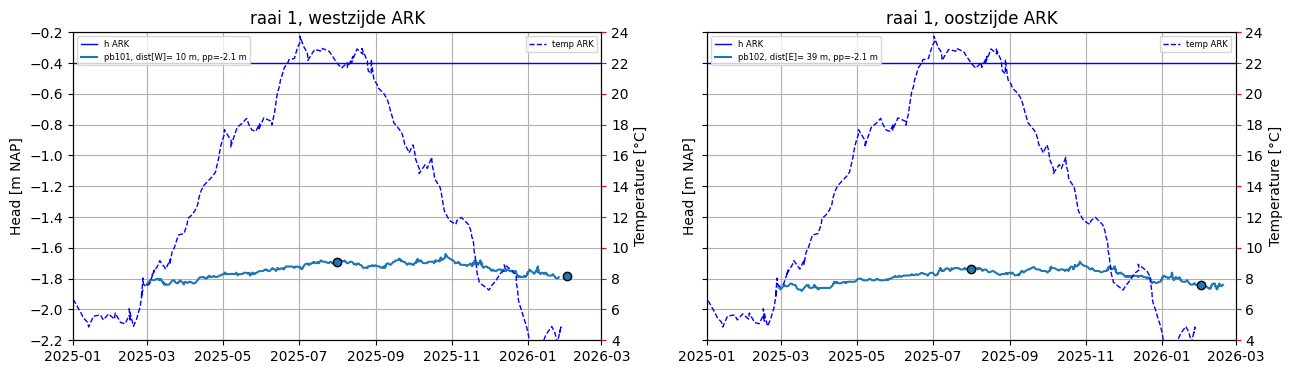

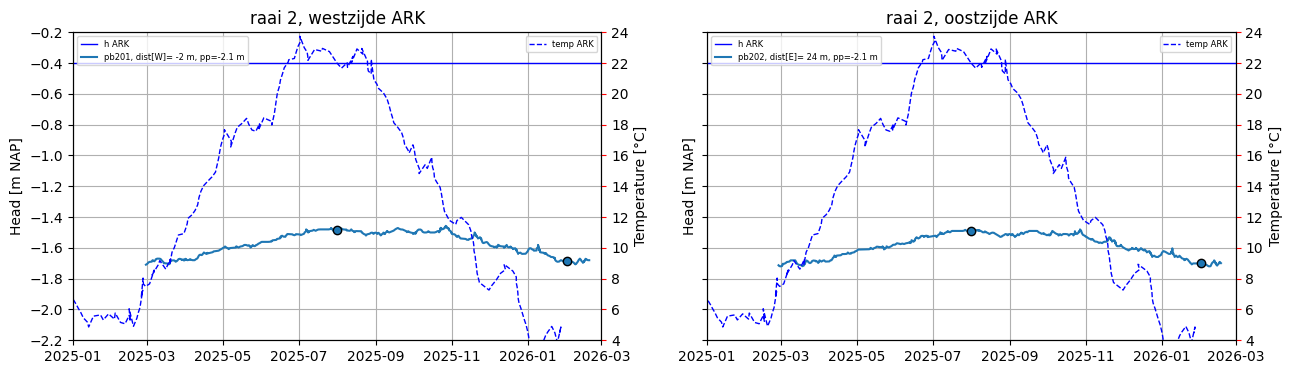

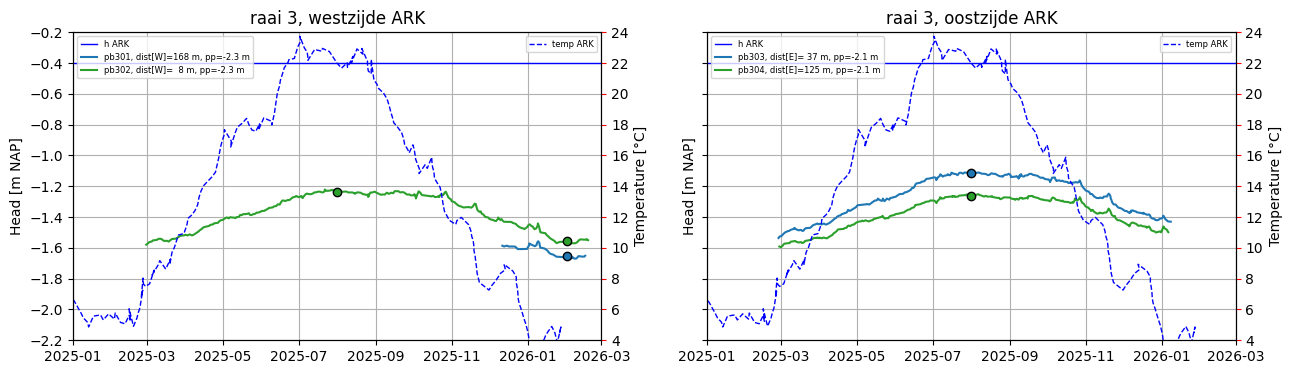

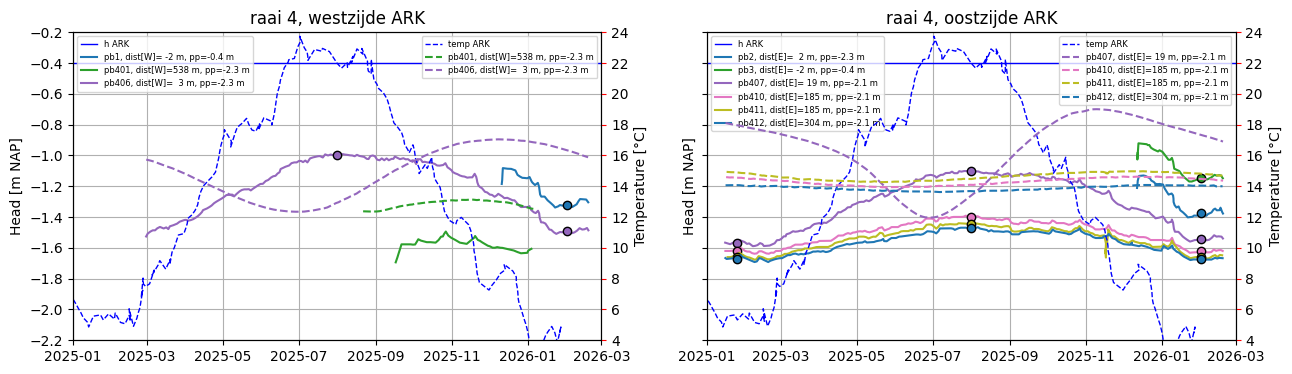

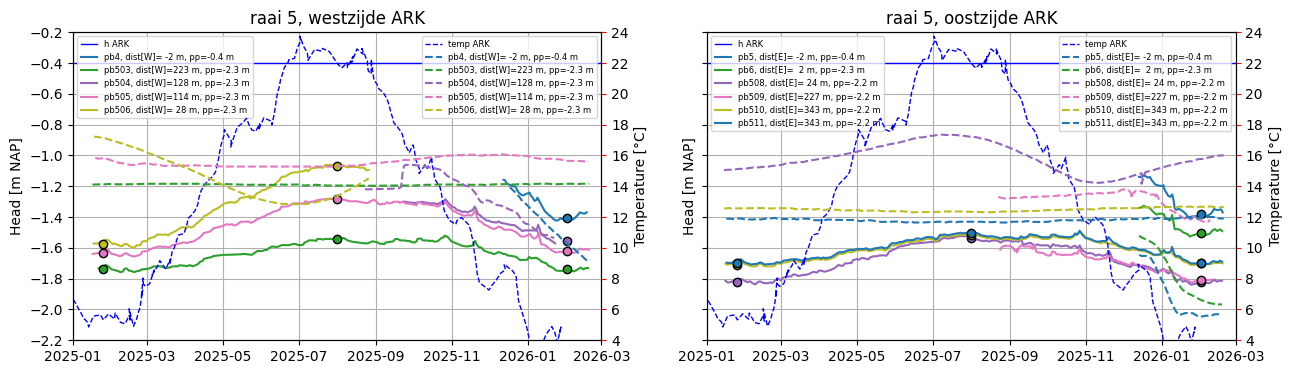

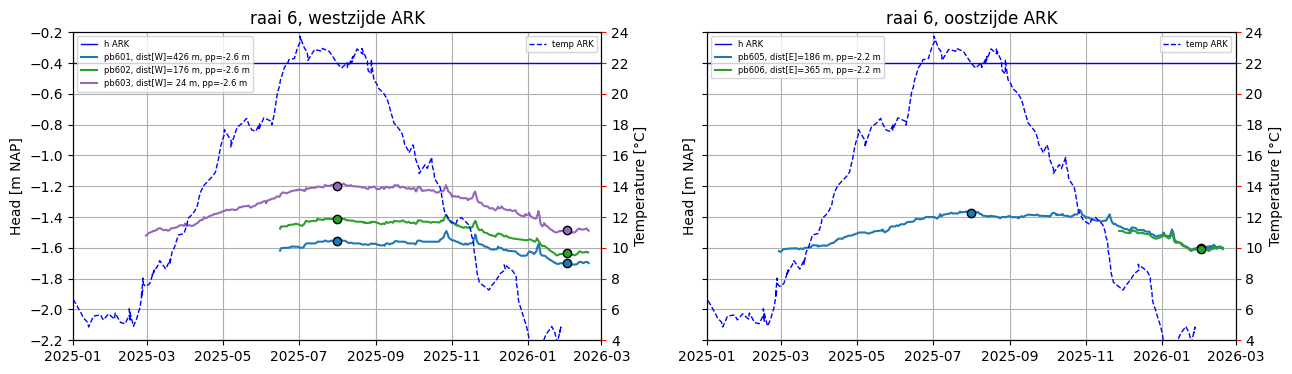

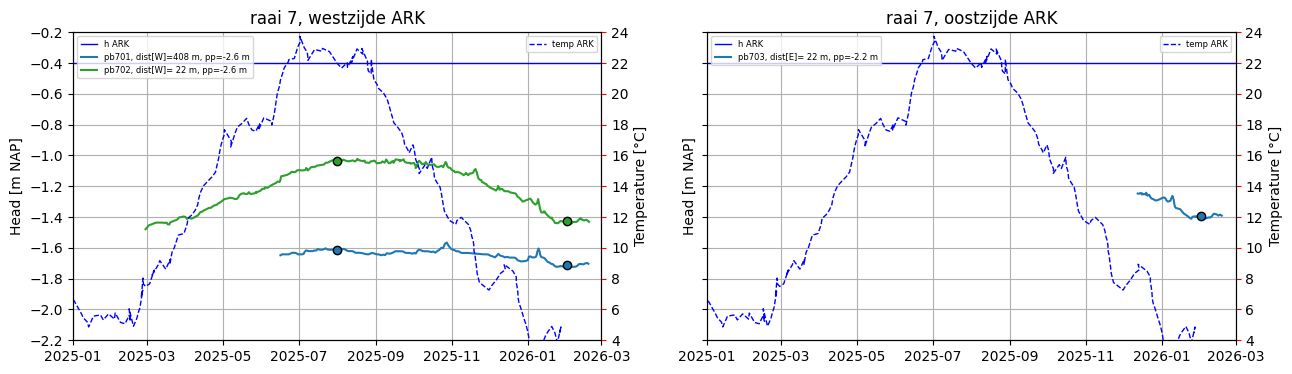

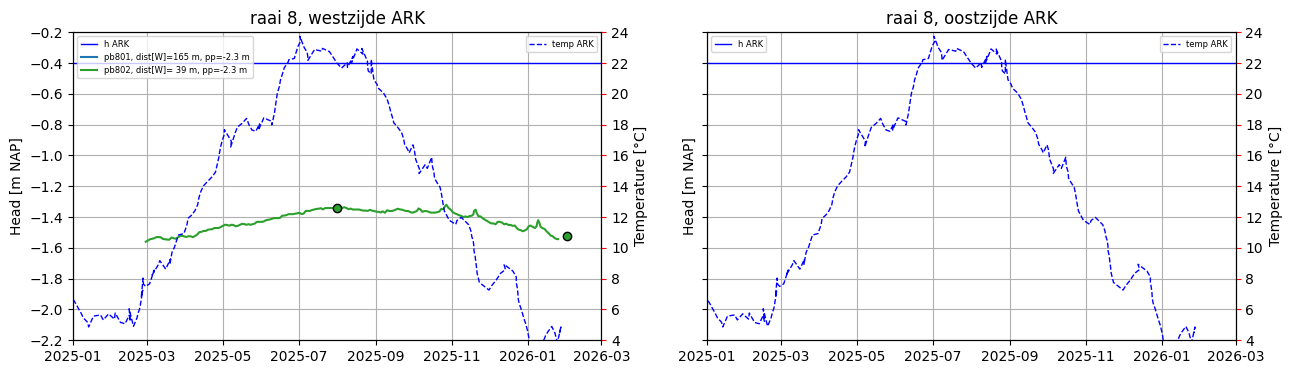

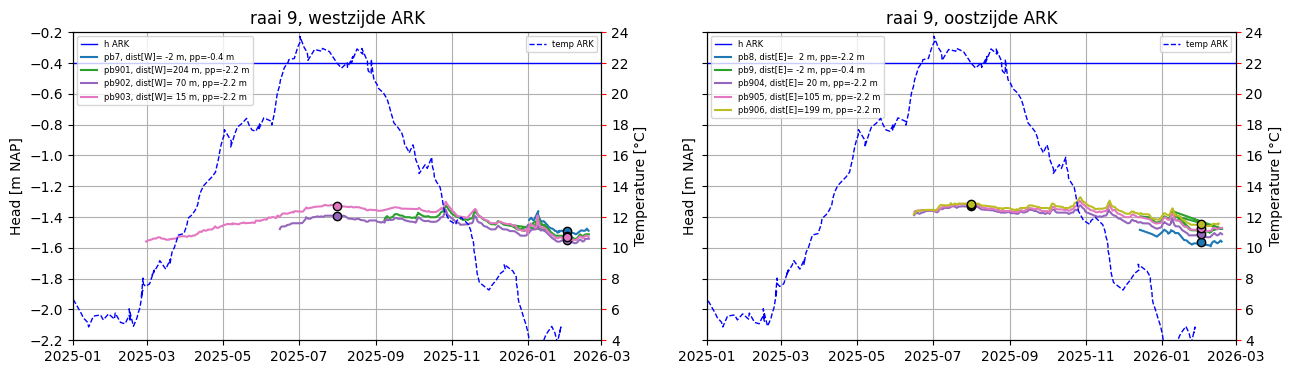

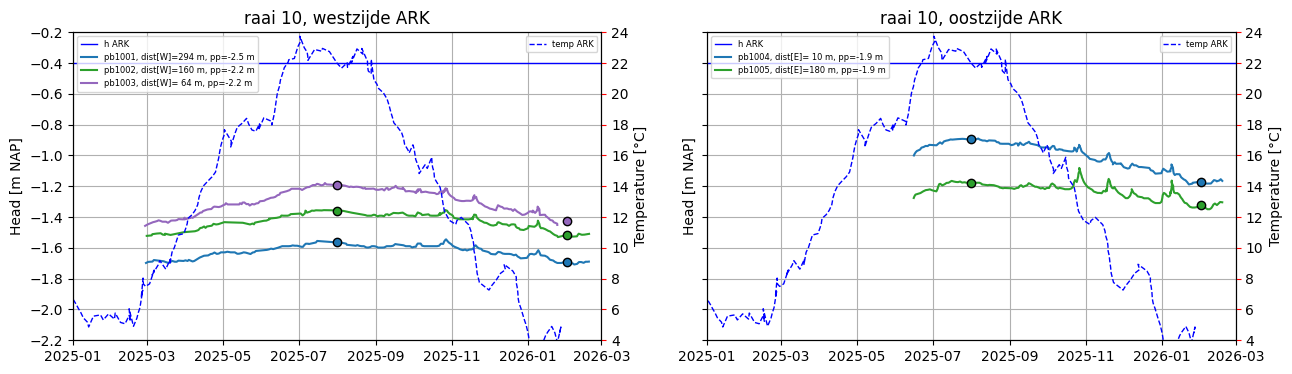

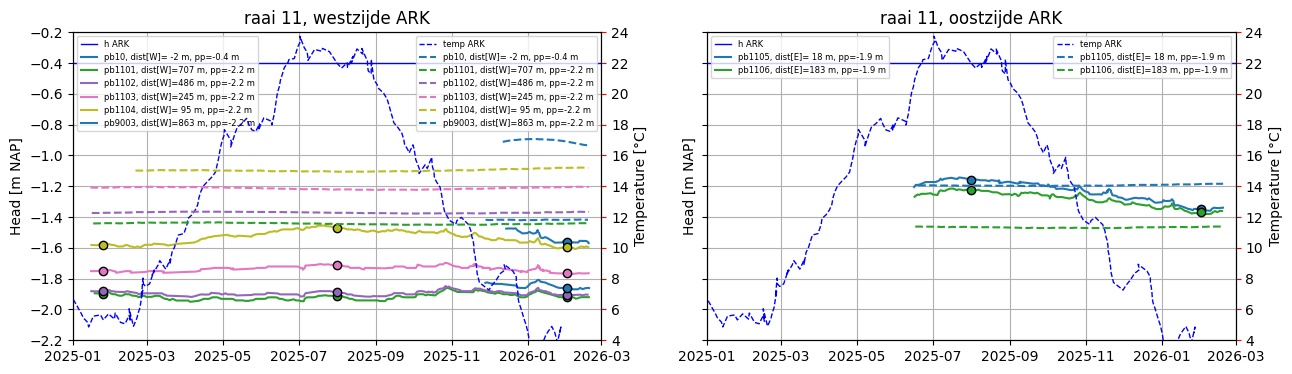

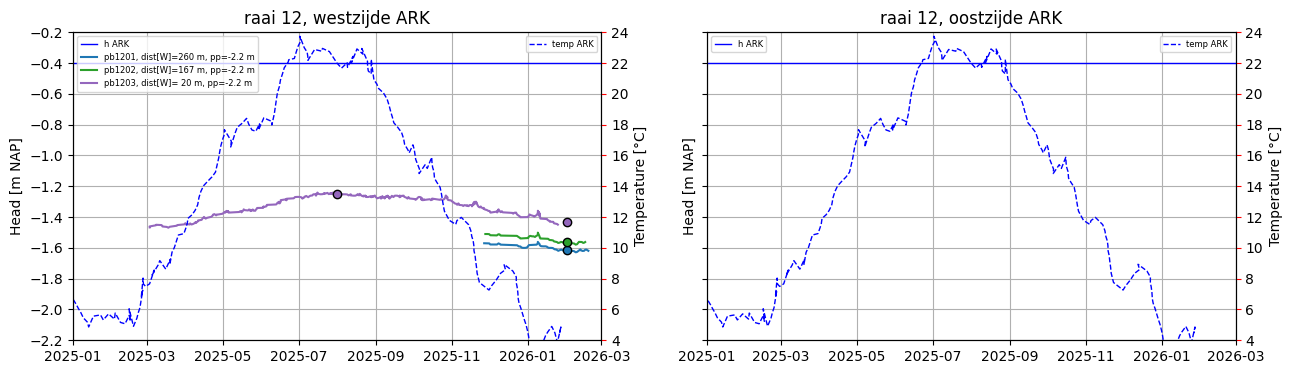

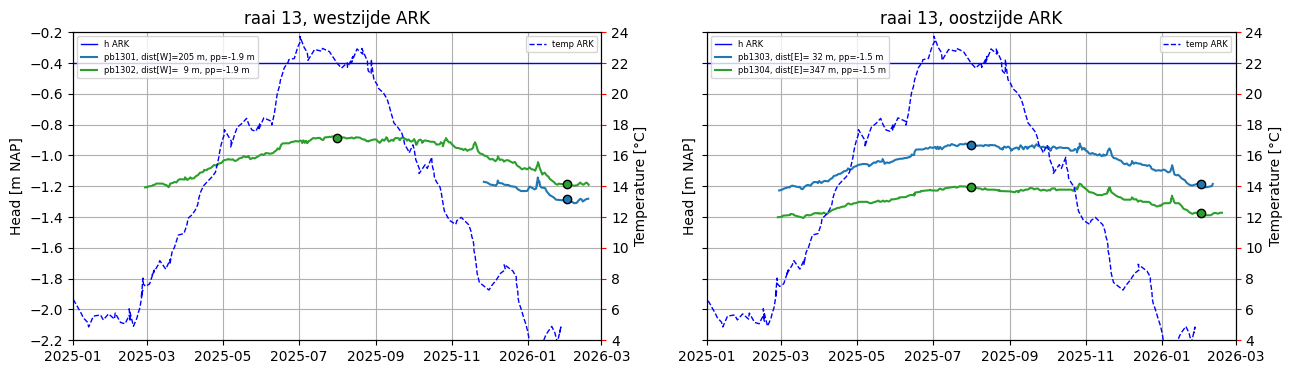

In [4]:
pbxy = Peilbuizen(os.path.join(dirs.pb_imag, 'pb_tauw_XY.xlsx'), sheet_name='pbTauw')
pbkan = Peilbuizen(os.path.join(dirs.pb_imag, 'pb_tauw_XY.xlsx'), sheet_name='pbKanaal')

# --- pd.DataFrame
pb_tauw_meta   = pbxy.data
pb_kanaal_meta = pbkan.data

b_ARK = 50

# --- Get ARK temperature
temp_ark = pd.read_csv(os.path.join(dirs.pb_data, 'tempARK_maarssen.csv'),
                       index_col=0, parse_dates=True)
temp_ark.columns=['temp']
temp_ark.index.name = 'datetime'


# --- Get dictionary with one fig for every row with 2 head and 2 overlapping temp axes
figaxs = {}
for raai in range(1, 14):
    fig, (axW, axE) = plt.subplots(1, 2, figsize=(15, 4), sharex=True, sharey=True)
    
    # logo(fig, NOTEBOOK_NAME)
    
    axW.set_title(f"raai {raai}, westzijde ARK")
    axE.set_title(f"raai {raai}, oostzijde ARK")
        
    xlim = (np.datetime64("2025-01-01"), np.datetime64("2026-03-01"))            
    axW.set_xlim(xlim)
    axE.set_xlim(xlim)
    
    ticks_h    = np.linspace(-2.2, -0.2, 11)
    ticks_temp = np.linspace(4, 24, 11)
    lim_h    = ticks_h[[0, -1]]
    lim_temp = ticks_temp[[0, -1]]
    
    axW.set_ylim(lim_h)
    axE.set_ylim(lim_h)
 
    axWT = axW.twinx()
    axET = axE.twinx()
    
    axET.set_ylabel("temp")
        
    axWT.set_ylim(lim_temp)
    axET.set_ylim(lim_temp)

    axW.set_yticks(ticks_h)
    axE.set_yticks(ticks_h)
    
    axWT.set_yticks(ticks_temp)
    axET.set_yticks(ticks_temp)
    
    axW.grid(True)
    axE.grid(True)
    
    axWT.tick_params(axis='y', color='red')
    axET.tick_params(axis='y', color='red')
    
    axW.set_ylabel('Head [m NAP]')
    axE.set_ylabel('Head [m NAP]')
    axWT.set_ylabel('Temperature [°C]')
    axET.set_ylabel('Temperature [°C]')
    
    hARK = -0.4
    axW.plot(xlim, [hARK, hARK], '-', color='blue', lw=1, label="h ARK") 
    axE.plot(xlim, [hARK, hARK], '-', color='blue', lw=1, label="h ARK")
    axWT.plot(temp_ark.index, temp_ark.loc[:, 'temp'], '--', color='blue', lw=1, label='temp ARK')
    axET.plot(temp_ark.index, temp_ark.loc[:, 'temp'], '--', color='blue', lw=1, label='temp ARK')

    figaxs[raai] = {'fig': fig, "axW":axW, "axE":axE, "axWT":axWT, "axET":axET}
    
Y = {}

# ---- Get data from these files, determine its row and plot head and temperature on the correct row head and temp axes
for fbn in [ 'pb[0-9].csv', 'pb10.csv', 'pb1[0-9][0-9].csv', 'pb2[0-9][0-9].csv', 'pb3[0-9][0-9].csv', 'pb4[0-9][0-9].csv',
            'pb5[0-9][0-9].csv', 'pb6[0-9][0-9].csv', 'pb7[0-9][0-9].csv', 'pb8[0-9][0-9].csv',
            'pb9[0-9][0-9].csv', 'pb10[0-9][0-9].csv', 'pb11[0-9][0-9].csv',
            'pb12[0-9][0-9].csv', 'pb13[0-9][0-9].csv', 'pb900[0-9].csv']:
    
    # --- current list of csv data files
    pb_csv_files = sorted(glob(os.path.join(dirs.pb_data, fbn)))

    # --- for each piezometer data csv file
    for fname in pb_csv_files:
        basename = os.path.basename(fname)        
        pb_idx = int(re.findall(r"(\d+)", basename)[0])
        try:
            # --- Normal drilled piezometer
            rec = pb_tauw_meta.loc[pb_idx]
        except Exception:
            # --- Then a sounding piezometer (not drilled) in or next to the ARK
            rec = pb_kanaal_meta.loc[pb_idx]
          
        # --- Specifics for this piezometer  
        raai = rec['raai']
        dist = rec['dist'] - b_ARK
        WE   = rec['WE']
        VP   = (rec['ZP'] + rec['WP']) / 2
                
        # --- knowing the row of this piezometer, get the correct figure and axes
        fig, axW, axE, axWT, axET = (figaxs[raai]['fig'],
                                     figaxs[raai]['axW'], figaxs[raai]['axE'],
                                     figaxs[raai]['axWT'], figaxs[raai]['axET'])
        
        # --- get the head data
        pb = pd.read_csv(fname, header=None, parse_dates=True, index_col=0)
        pb.columns=['h']
        pb.index.name = 'datetime'
        
        t = pb.index
        y = pb.loc[:, 'h'].values
        
        # --- we want the min and max (average over 1 month around occuring dates)
        mask1 = np.logical_and(t>np.datetime64("2025-01-01"), t < np.datetime64("2025-02-20"))
        mask2 = np.logical_and(t>np.datetime64("2025-07-15"), t < np.datetime64("2025-08-15"))
        mask3 = np.logical_and(t>np.datetime64("2026-01-15"), t < np.datetime64("2026-03-01"))
        
        # --- Get these special values
        y1 = np.round(np.median(y[mask1]), 3)
        y2 = np.round(np.median(y[mask2]), 3)
        y3 = np.round(np.median(y[mask3]), 3)
        # print(f"{basename[:-4]:6} {raai} {y1}, {y2}, {y3}")
        
        # --- Store these data in dict
        tt = [np.datetime64("2025-01-25"), np.datetime64("2025-08-01"), np.datetime64("2026-02-01")]
        Y[basename[:-4]] ={'t':tt, 'h':[y1, y2, y3]}
        
        # --- Is this piezometer located to the west or the east of the ARK canal?
        # --- Use correct axes
        if WE=='W':
            ax=axW
        else:
            ax=axE
        # --- plot time series
        ln, = ax.plot(t, y, label=f"{basename[:-4]}, dist[{WE}]={dist:3.0f} m, pp={VP:.2} m")
        clr = ln.get_color()

        # --- special points
        ax.plot(tt, [y1, y2, y3], 'o', mfc=clr, mec='k')
        
        # --- Second part, add temperature
        # --- same name but "temp_" prepended
        fname_temp = os.path.join(dirs.pb_data, f'temp_pb{pb_idx}.csv')
        try:
            pb_temp = pd.read_csv(fname_temp, header=None, parse_dates=True, index_col=0)
            pb_temp.columns=['temp']
            pb_temp.index.name = 'datetime'
        except FileNotFoundError:
            # --- if the temp .csv file does not exist for this piezometer, skip it
            continue
        
        # --- Plot the temperature time series on the correct axes and with same color as the head
        t_temp = pb_temp.index
        y_temp = pb_temp.loc[:, 'temp'].values
        
        if WE=='W':
            ax=axWT
        else:
            ax=axET
        ax.plot(t_temp, y_temp, '--', color=clr, label=f"{basename[:-4]}, dist[{WE}]={dist:3.0f} m, pp={VP:.2} m")

# --- Finally set the legends for all axes
for raai, figax in figaxs.items():    
    figax['axW'].legend(loc='upper left', fontsize=6)
    figax['axE'].legend(loc='upper left', fontsize=6)
    figax['axWT'].legend(loc='upper right', fontsize=6)
    figax['axET'].legend(loc='upper right', fontsize=6)
    
    
print("Month-averaged head around the 3 dates given min, max and min values")
for fn, data in Y.items():
    print(f"{fn},{data['t'][0]},{data['t'][1]},{data['t'][2]},{data['h'][0]},{data['h'][1]},{data['h'][2]}")

In [ ]:
for raai, figax in figaxs.items():
    save_name = f"h_temp_raai{raai}.pdf"
    fig_path = os.path.join(dirs.images, save_name)    
    figax['fig'].savefig(fig_path)
    print(f"fig raai {raai} saved to: {fig_path}")
        
# pb, t, y

raai4, WE=W, tcol=summer, sum(mask)=1
raai4, WE=W, tcol=winter, sum(mask)=2
raai4, WE=E, tcol=summer, sum(mask)=1
raai4, WE=E, tcol=winter, sum(mask)=2
raai5, WE=W, tcol=summer, sum(mask)=3
raai5, WE=W, tcol=winter, sum(mask)=4
raai5, WE=E, tcol=summer, sum(mask)=3
raai5, WE=E, tcol=winter, sum(mask)=4
raai6, WE=W, tcol=summer, sum(mask)=3
raai6, WE=W, tcol=winter, sum(mask)=3
raai6, WE=E, tcol=summer, sum(mask)=3
raai6, WE=E, tcol=winter, sum(mask)=3
raai11, WE=W, tcol=summer, sum(mask)=4
raai11, WE=W, tcol=winter, sum(mask)=6
raai11, WE=E, tcol=summer, sum(mask)=4
raai11, WE=E, tcol=winter, sum(mask)=6


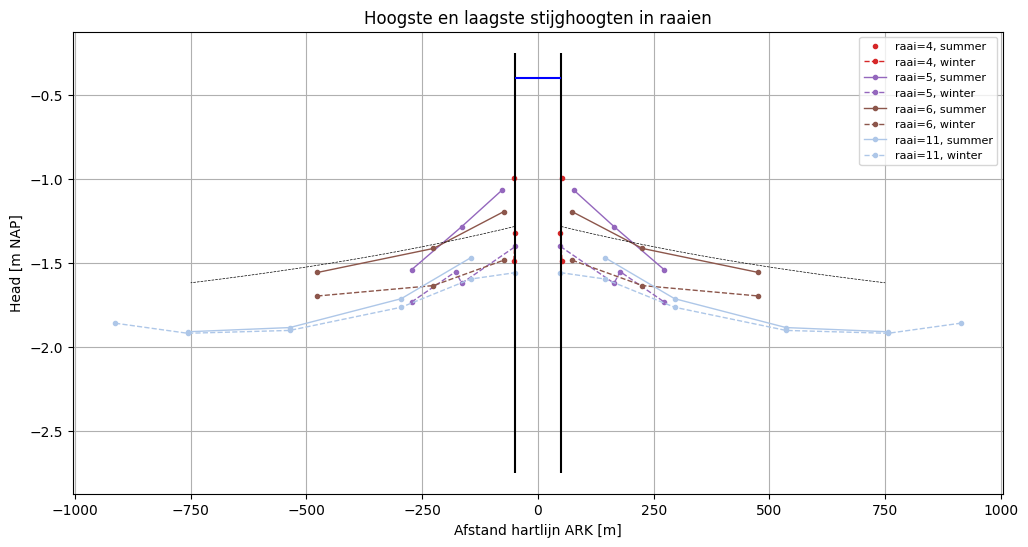

In [5]:
pbxy = Peilbuizen(os.path.join(dirs.pb_imag, 'pb_tauw_XY.xlsx'), sheet_name='joined')

# --- pd.DataFrame
pb_meta = pbxy.data

bARK = 50
kD, c = 1000., 1000.
lam = np.sqrt(kD * c)
y0, yb = -1.25, -1.95

x_ = np.linspace(bARK, 750, 71)
y_ = yb + (y0 - yb) * np.exp(-x_ / lam)
ax.plot(x_,  y_)
ax.plot(-x_, y_)

fig, ax = plt.subplots(figsize=(12,6))
ax.set_title("Hoogste en laagste stijghoogten in raaien")
ax.set_xlabel("Afstand hartlijn ARK [m]")
ax.set_ylabel("Head [m NAP]")

colors = [
    '#1f77b4',  # blue
    '#ff7f0e',  # orange
    '#2ca02c',  # green
    '#d62728',  # red
    '#9467bd',  # purple
    '#8c564b',  # brown
    '#e377c2',  # pink
    '#7f7f7f',  # gray
    '#bcbd22',  # olive
    '#17becf',  # cyan
    '#aec7e8',  # light blue
    '#ffbb78',  # light orange
    '#98df8a',  # light green
]


for raai in np.unique(pb_meta['raai']):
    if raai not in [4, 5, 6, 11]:
        continue
    for WE in ['W', 'E']:
        for tcol in ['summer', 'winter']:
            mask = (pb_meta['raai'] == raai) & (pb_meta['WE'] == 'W') & (pb_meta[tcol] != 0)
            print(f"raai{raai}, WE={WE}, tcol={tcol}, sum(mask)={np.sum(mask)}")
            n = np.sum(mask)
            if n < 1:
                continue
            x = pb_meta.loc[mask, 'dist'].values
            y = pb_meta.loc[mask, tcol].values
            
            if WE == 'W':
                x = -x
                label=f"raai={raai}, {tcol}"                
            else:
                label=""                
                
            if tcol == 'summer':
                ls = '-'
            else:
                ls = '--'
                            
                
            if n == 1:
                ax.plot(x, y, 'o', ms=3, color=colors[raai - 1], label=label)
            else:
                if tcol == tcol[1]:
                    lw = 2
                else:
                    lw = 1
                ix = np.argsort(x)
                ax.plot(x[ix], y[ix], marker='o', ms=3, ls=ls, color=colors[raai - 1], lw=lw, label=label)
ax.grid()
ax.vlines([-bARK, bARK], ymin=-2.75, ymax=-0.25, colors=['k'])
ax.hlines([-0.4], xmin=-bARK, xmax=+bARK, colors='b')

ax.legend(fontsize=8)

ax.plot(-x_, y_, 'k--', lw=0.5)
ax.plot(+x_, y_, 'k--', lw=0.5)


x = np.linspace(50, 750, 101)


# Cross section model basid on best estimates of conductivities

In [82]:
def get_analytical_props(gr, lagen, DRN):
    """Return aquifer props for analytical comparison.
    
    Returns
    -------
    kD: float
        transmissivity of the layers below the cover layer.
    c: float
        resistance of the cover layer (D/kv)
    cDRN: float
        median resistance by the drains (add to c in model)
        normally all values are the same unless changed in code.
        cDRN = dx / C [m/(d/m2])] = [d]
    """
    deklaag = lagen['geo'] == 'Niewkoop'
    wvps = lagen['okLaag'] < lagen.loc[deklaag, 'okLaag'].values[0]
    sdps = lagen['okLaag'] >= lagen.loc[deklaag, 'okLaag'].values[0]

    kD = (lagen.loc[wvps, 'kh']  * lagen.loc[wvps, 'D']).sum()
    c = (lagen.loc[sdps, 'D'] / lagen.loc[sdps, 'kv']).sum().round()
    cDRN = np.median(gr.DX.ravel()[DRN['Ig']] / DRN['C']).round(1)
    return kD, c, cDRN



# === Not too simple Xsec ARK model for testing ====

L = 10000. # --- Half width of model

# --- width, head, z sludge layer, z bottom
bARK, hARK, z_slib_ARK, zARK = 50., -0.4, -6.2, -6.7

ddw, zdw = 0.5, -10 # Thicknes of sheet piling
pp = -2.3 # Polder head levels

# --- Resisntaces
c_ARK_slib, c_drainage = 12., 750.

# --- Definition of geological layers --> store in pd.DataFrame
columns = ['bkLaag', 'okLaag', 'kh', 'kv', 'geo', 'lith', 'fc']
data = np.array([[ -2.,  -2.5, 0.2, 0.02,  'Echteld', 'zk - k', 'darkgreen'],
                 [ -2.5, -6.0, 1.0, 0.010, 'Niewkoop', 'veen',   'brown'],
                 [ -6.0, -50., 15., 1.5,   'BX-DR', 'fz - gz','gold'],
                 [-50.,  -60., 0.2, 0.2,   'Waalre', 'klei',   'green'],
                 [-60., -160., 30., 10.,   'Peize', 'gz',     'yellow']])
lagen = pd.DataFrame(data, columns=columns)
lagen[columns[:4]] = lagen[columns[:4]].astype(float)

# --- Add additional property columns
lagen['D'] = lagen['bkLaag'] - lagen['okLaag']
lagen['kD'] = lagen['D'] * lagen['kh']
lagen['c']  = lagen['D'] / lagen['kv']

# --- The grid (combine specific z-coordinates, the layers and an overal refined enough grid)
z = np.unique(np.hstack((zdw, zARK, zARK + 0.5, lagen['bkLaag'], lagen['okLaag'], np.linspace(0, -160, 41))))[::-1]

# --- The x-grid
x1_ = bARK - np.logspace(0, np.log10(bARK), 10)      # --- inside the ARK
x2_ = np.logspace(np.log10(bARK), np.log10(L), 50)   # --- outside the ARK
x3_ = bARK + np.array([-1, 1, 2]) * ddw              # --- detail, side of canal

x = np.unique(np.hstack((0, 0.5, x1_, x2_, x3_, L - 1))) # --- combine all

gr = mfgrid.Grid(x, None, z)

# --- Matrix / cell properties
kh = gr.const(0)
kv = gr.const(0)

# --- Fill each geol layer
for lg in lagen.index:
    laag = lagen.loc[lg, :]
    mask = (gr.ZM > laag['okLaag']) & (gr.ZM < laag['bkLaag'])
    kh[mask] = laag['kh']
    kv[mask] = laag['kv']
   
# --- Special for the ARK water body and its sludge bottom 
mask_ARK = (gr.ZM > zARK) & (gr.XM < bARK) & (gr.XM > -bARK)
mask_ARK_slib = mask_ARK & (gr.ZM < z_slib_ARK)

# --- Layer blow sludge and bottom ARK
iz = np.searchsorted(-gr.z, -zARK - 0.5) + 1
mask_below_slib = (gr.ZM == gr.zm[iz]) & (gr.xm < bARK)

kh[mask_ARK] = 1000.
kv[mask_ARK] = 1000.
kv[mask_ARK_slib] = gr.DZ[mask_ARK_slib] / c_ARK_slib / 2

# --- The sheet pilings
mask_damw = (gr.ZM > zdw) & (
                ((gr.XM > +bARK) & (gr.XM < bARK + ddw)) |
                ((gr.XM < -bARK) & (gr.XM > bARK - ddw))
)

# --- Boundary array (define fixed head heads and inactive cells)
IBOUND = gr.const(1, dtype=int)
IBOUND[mask_ARK]  = -1
IBOUND[mask_damw] = 0

# --- Fixed flows (not now, all zero)
FQ = gr.const(0.)

# --- Starting heads
HI = gr.const(pp)
HI[mask_ARK] = hARK

# --- DRN boundary condition in top layer (polder)
mask_pold = (gr.ZM > pp) & (gr.ZM < gr.z[0]) & (gr.XM > bARK + ddw)

# --- Global cell indices of DRN locations
xyz = np.vstack((gr.XM[mask_pold], gr.YM[mask_pold], gr.ZM[mask_pold])).T
Ig = gr.Iglob_from_xyz(xyz)

# --- Fill DRN 
DRN = np.zeros(len(xyz), dtype=fdm3Blom.Fdm3.dtypes['drn'])
DRN['Ig'] = Ig
DRN['C'] = gr.DX.ravel()[Ig] / c_drainage     # --- convert overall drainage c to conductances
DRN['h'] = pp                                 # --- Polder level

# --- Set up the FDM model
mdl = fdm3Blom.Fdm3(gr, K=(kh, kh, kv), S=None, IBOUND=IBOUND, HI=HI, FQ=FQ)
# --- Run it
out = mdl.simulate(tm=[1, 1.5], DRN=DRN)

# --- Define funcion to fill x-section with colored patches
def get_patches(ax):
    for lg in lagen.index:
        rec = lagen.loc[lg]
        extent = (gr.x[0], gr.x[-1], rec['okLaag'], rec['bkLaag'])
        R = Rectangle((extent[0], extent[2]), extent[1] - extent[0], extent[3] - extent[2], fc=rec['fc'])
        ax.add_patch(R)
    ax.add_patch(Rectangle((0, zARK), bARK, hARK - zARK, fc='blue', zorder=4)) # ARK waterlichaam
    ax.add_patch(Rectangle((+bARK, zdw), +ddw, 0 - zdw, fc='k', zorder=4))     # Damwand
    ax.add_patch(Rectangle((-bARK, zdw), -ddw, 0 - zdw, fc='k', zorder=4))     # Damwand
    ax.add_patch(Rectangle((0, -zARK), 0, bARK, fc='gray', zorder=5)) # Kanaalbodem
    
# --- We want the head along the top of the first and second aquifers
itop_WVP1 = np.searchsorted(-gr.z, -lagen.loc[1, 'okLaag'])
itop_WVP2 = np.searchsorted(-gr.z, -lagen.loc[3, 'okLaag'])

# --- The masks for the top of the first and second aquifers
top_WVP1 = (gr.ZM == gr.zm[itop_WVP1])
top_WVP2 = (gr.ZM == gr.zm[itop_WVP2])


Non-linear options: ['DRN'], starting outer iterations:
iouter =    0, err =      1.386 m, errBalance =      1.977
iouter =    1, err =    0.19254 m, errBalance =     1.4615
iouter =    2, err =    0.10014 m, errBalance =      1.169
iouter =    3, err =   0.051855 m, errBalance =     0.7949
iouter =    4, err =   0.023202 m, errBalance =    0.43097
iouter =    5, err =  0.0083848 m, errBalance =    0.17507
iouter =    6, err =   0.002306 m, errBalance =   0.050797
iouter =    7, err =  0.0004563 m, errBalance =       0.01
iouter =    8, err = 6.2069e-05 m, errBalance =  0.0013161
iouter =    9, err = 5.6607e-06 m, errBalance = 0.00011349
iouter =   10, err = 3.4557e-07 m, errBalance = 6.9774e-06
iouter =   11, err = 1.3959e-08 m, errBalance = 1.0916e-07
Converged, normal termination.

===== Water balance of the entire model =====
Model grid = (47, 1, 64)

Sum over all nodal flows should be zero:
Total net in Q1     =  3.388e-11 m3/d

Boundary components, these components should also ad

/Users/Theo/Development/python/hydro_tools/tools/fdm/src/fdm3Blom.py:234: RuntimeWarning: divide by zero encountered in divide
  Rx2 = 0.5 * dx / (dy * dz) / kx
/Users/Theo/Development/python/hydro_tools/tools/fdm/src/fdm3Blom.py:235: RuntimeWarning: divide by zero encountered in divide
  Rx1 = 0.5 * dx / (dy * dz) / kx
/Users/Theo/Development/python/hydro_tools/tools/fdm/src/fdm3Blom.py:236: RuntimeWarning: divide by zero encountered in divide
  Ry  = 0.5 * dy / (dz * dx) / ky
/Users/Theo/Development/python/hydro_tools/tools/fdm/src/fdm3Blom.py:237: RuntimeWarning: divide by zero encountered in divide
  Rz  = 0.5 * dz / (dx * dy) / kz


# Plot the results of the model

/Users/Theo/Development/python/hydro_tools/tools/fdm/src/mfgrid.py:2020: UserWarning: This only works when all flow is within plane zx given by row
  warnings.warn("This only works when all flow is within plane zx given by row")


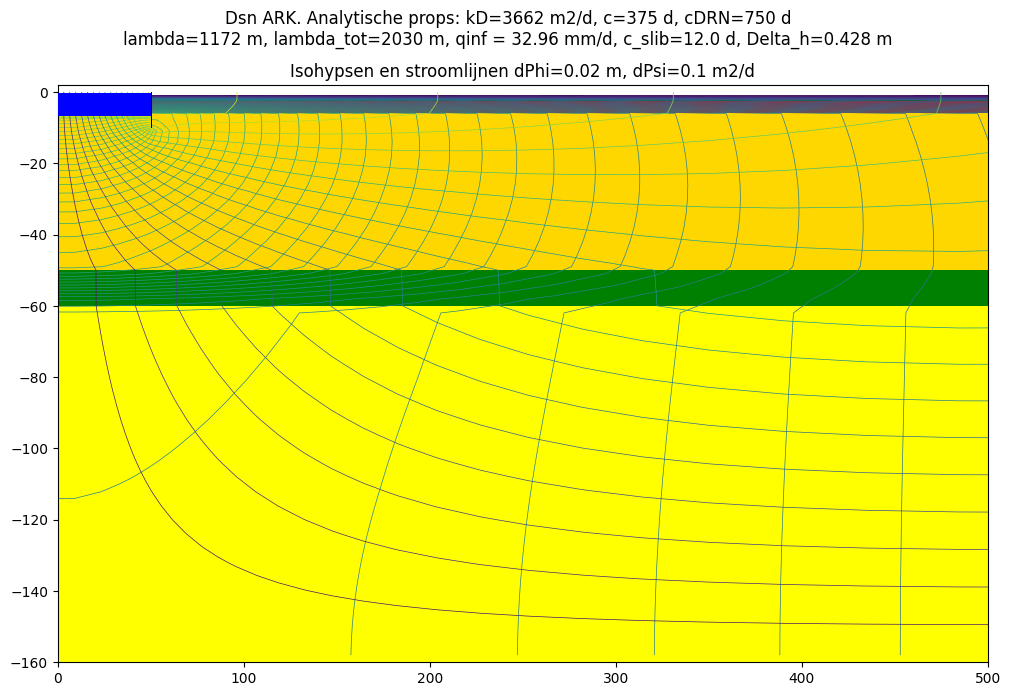

In [83]:
# --- step size of isohypses and stream function lines
dphi, dpsi = 0.02, 0.1

# --- get levels for  contouring
phi_min, phi_max = np.round(np.nanmin(out['Phi']) * 100) / 100, np.round(np.nanmax(out['Phi']) * 100) / 100
phi_levels = np.arange(phi_min, phi_max + dphi, dphi)

psi = gr.psi_row(out['Qx'], row=0)
psi_min, psi_max = np.round(np.nanmin(psi) * 100) / 100, np.round(np.nanmax(psi) * 100) / 100
psi_levels = np.arange(psi_min, psi_max + dpsi, dpsi)

# --- View window
ylim = (None, 2)
xlim = (0, 500)

# --- Plot of cross section
fig, ax = plt.subplots(figsize=(12, 7.5))

# --- Patch to show layers in colors
get_patches(ax)

# --- Contour heads and stream lines
Ch = ax.contour(gr.XM[:,0,:], gr.ZM[:,0,:], out['Phi'][:, 0, :], levels=phi_levels, linewidths=0.5)
Cp = ax.contour(gr.X[:,0,1:-1], gr.Z[:, 0, :-1], psi, levels=psi_levels, linewidths=0.5)

# --- Compute the analytical properties of this aquifer
kD, c, cDRN = get_analytical_props(gr, lagen, DRN)
lam = np.sqrt(kD * c).round()
lam_tot = np.sqrt(kD * (c + cDRN)).round()

# --- Infiltration and resistance
c_ARK_slib = (0.5 * gr.DZ[mask_ARK_slib]) / kv[mask_ARK_slib]
Qinf = out['Q'][mask_ARK_slib]
qinf = Qinf.sum() / bARK
Delta_h = out['Phi'][mask_ARK_slib].mean() - out['Phi'][mask_below_slib].mean()

# --- Suptitle with details of this cross section.
supttl = (
    f"Dsn ARK. Analytische props: kD={kD:.0f} m2/d, c={c:.0f} d, cDRN={cDRN:.0f} d\n" +
    f"lambda={lam:.0f} m, lambda_tot={lam_tot:.0f} m, qinf = {qinf * 1000:.4} mm/d, c_slib={c_ARK_slib.mean():.1f} d, Delta_h={Delta_h:.3f} m"
)
fig.suptitle(supttl)
ax.set_title(f"Isohypsen en stroomlijnen dPhi={dphi} m, dPsi={dpsi} m2/d")
ax.set_xlim(xlim)
ax.set_ylim(ylim)

plt.show()

# Plot head along the top of the first and second aquifers

raai4, WE=W, tcol=summer, sum(mask)=1
raai4, WE=W, tcol=winter, sum(mask)=2
raai4, WE=E, tcol=summer, sum(mask)=1
raai4, WE=E, tcol=winter, sum(mask)=2
raai5, WE=W, tcol=summer, sum(mask)=3
raai5, WE=W, tcol=winter, sum(mask)=4
raai5, WE=E, tcol=summer, sum(mask)=3
raai5, WE=E, tcol=winter, sum(mask)=4
raai6, WE=W, tcol=summer, sum(mask)=3
raai6, WE=W, tcol=winter, sum(mask)=3
raai6, WE=E, tcol=summer, sum(mask)=3
raai6, WE=E, tcol=winter, sum(mask)=3
raai11, WE=W, tcol=summer, sum(mask)=4
raai11, WE=W, tcol=winter, sum(mask)=6
raai11, WE=E, tcol=summer, sum(mask)=4
raai11, WE=E, tcol=winter, sum(mask)=6


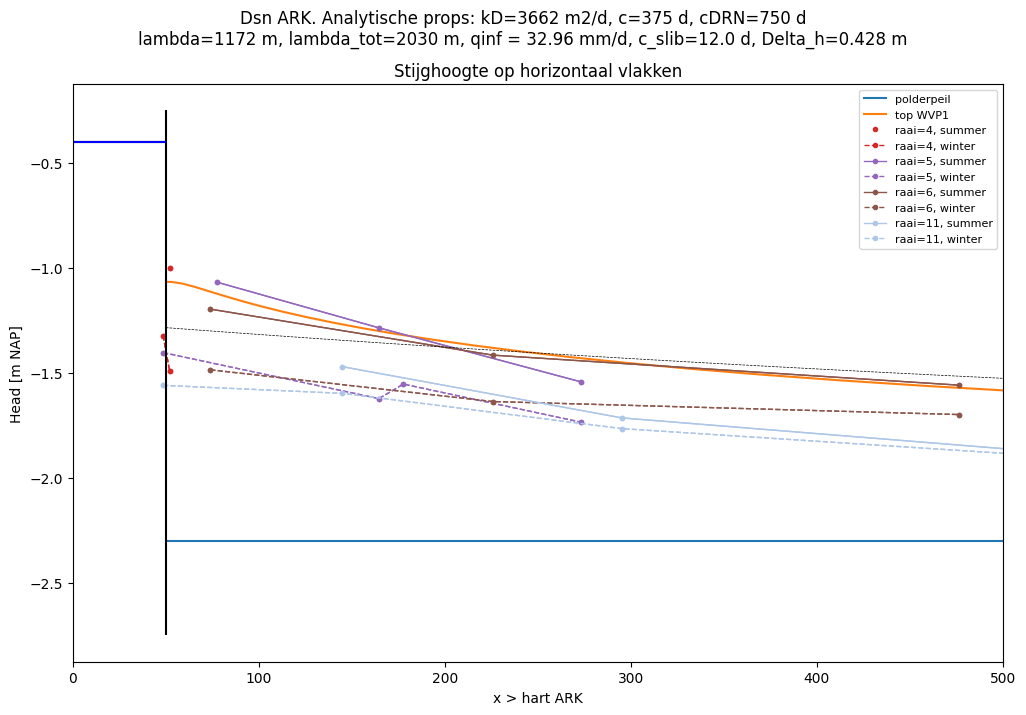

In [84]:
fig, ax = plt.subplots(figsize=(12, 7.5))

ax.plot(gr.xm,  out['Phi'][0,0,:], label='polderpeil')
ax.plot(gr.xm, out['Phi'][top_WVP1], label='top WVP1')
# ax.plot(gr.xm, out['Phi'][top_WVP2], label='top WVP2')

fig.suptitle(supttl)
ax.set_title("Stijghoogte op horizontaal vlakken")
ax.set_xlabel('x > hart ARK')
ax.set_ylabel('Head [m NAP]')
ax.grid()
ax.set_xlim(xlim)
ax.legend()

# === Add heads measured in cross sections perpendicular to the ARK

for raai in np.unique(pb_meta['raai']):
    if raai not in [4, 5, 6, 11]:
        continue
    for WE in ['W', 'E']:
        for tcol in ['summer', 'winter']:
            mask = (pb_meta['raai'] == raai) & (pb_meta['WE'] == 'W') & (pb_meta[tcol] != 0)
            print(f"raai{raai}, WE={WE}, tcol={tcol}, sum(mask)={np.sum(mask)}")
            n = np.sum(mask)
            if n < 1:
                continue
            x = pb_meta.loc[mask, 'dist'].values
            y = pb_meta.loc[mask, tcol].values
            
            if WE == 'W':
                # x = -x  3 For now all on the positive x-axis
                label=f"raai={raai}, {tcol}"                
            else:
                label=""                
                
            if tcol == 'summer':
                ls = '-'
            else:
                ls = '--'
                            
                
            if n == 1:
                ax.plot(x, y, 'o', ms=3, color=colors[raai - 1], label=label)
            else:
                if tcol == tcol[1]:
                    lw = 2
                else:
                    lw = 1
                ix = np.argsort(x)
                ax.plot(x[ix], y[ix], marker='o', ms=3, ls=ls, color=colors[raai - 1], lw=lw, label=label)
ax.grid()
ax.vlines([-bARK, bARK], ymin=-2.75, ymax=-0.25, colors=['k'])
ax.hlines([-0.4], xmin=-bARK, xmax=+bARK, colors='b')

ax.legend(fontsize=8)

ax.plot(-x_, y_, 'k--', lw=0.5)
ax.plot(+x_, y_, 'k--', lw=0.5)




In [33]:
# --- c_slib
0.5 * gr.DZ[mask_ARK_slib] / kv[mask_ARK_slib]

array([30., 30., 30., 30., 30., 30., 30., 30., 30., 30., 30., 30.])

In [31]:
# -- kv_slib
gr.DZ[mask_ARK_slib] / c_ARK_slib / 2

array([0.00208333, 0.00208333, 0.00208333, 0.00208333, 0.00208333,
       0.00208333, 0.00208333, 0.00208333, 0.00208333, 0.00208333,
       0.00208333, 0.00208333])

In [32]:
kv[mask_ARK_slib]

array([0.00833333, 0.00833333, 0.00833333, 0.00833333, 0.00833333,
       0.00833333, 0.00833333, 0.00833333, 0.00833333, 0.00833333,
       0.00833333, 0.00833333])

In [9]:
out['Qz'][:10, 0, :3] / gr.DX[:10, 0, :3]

array([[ 0.        ,  0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        ],
       [-0.02816862, -0.02817866, -0.02875128],
       [-0.0270394 , -0.02704951, -0.02764237],
       [-0.02522636, -0.02523452, -0.02572641],
       [-0.02333925, -0.02334119, -0.02345539],
       [-0.01951234, -0.01949997, -0.01877841]])

In [10]:
out['Phi'][:10, 0, :3]

array([[-0.4       , -0.4       , -0.4       ],
       [-0.4       , -0.4       , -0.4       ],
       [-0.4       , -0.4       , -0.4       ],
       [-0.4       , -0.4       , -0.4       ],
       [-0.4       , -0.4       , -0.4       ],
       [-0.4       , -0.4       , -0.4       ],
       [-1.11642197, -1.11667714, -1.13124087],
       [-1.1461653 , -1.14643161, -1.16164747],
       [-1.17980045, -1.18007764, -1.19594935],
       [-1.22647896, -1.22676001, -1.24286013]])

In [11]:
np.round(out['Q'][:10, 0, :3] * 100000) / 100 / gr.DX[:10, 0, :3]

array([[-0.        ,  0.        , -0.        ],
       [-0.        ,  0.        ,  0.        ],
       [-0.        , -0.        , -0.        ],
       [ 0.        , -0.        ,  0.        ],
       [-0.        , -0.        ,  0.        ],
       [28.16      , 28.17869399, 28.75093066],
       [ 0.        ,  0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        ],
       [-0.        ,  0.        ,  0.        ]])

In [12]:
kv[:10,0,:3]

array([[1.0e+03, 1.0e+03, 1.0e+03],
       [1.0e+03, 1.0e+03, 1.0e+03],
       [1.0e+03, 1.0e+03, 1.0e+03],
       [1.0e+03, 1.0e+03, 1.0e+03],
       [1.0e+03, 1.0e+03, 1.0e+03],
       [1.0e-02, 1.0e-02, 1.0e-02],
       [1.5e+00, 1.5e+00, 1.5e+00],
       [1.5e+00, 1.5e+00, 1.5e+00],
       [1.5e+00, 1.5e+00, 1.5e+00],
       [1.5e+00, 1.5e+00, 1.5e+00]])

In [13]:
gr.DZ[:10,0,:3]


array([[2. , 2. , 2. ],
       [0.5, 0.5, 0.5],
       [1.5, 1.5, 1.5],
       [2. , 2. , 2. ],
       [0.2, 0.2, 0.2],
       [0.5, 0.5, 0.5],
       [1.3, 1.3, 1.3],
       [2. , 2. , 2. ],
       [2. , 2. , 2. ],
       [4. , 4. , 4. ]])

In [14]:
IBOUND[:10,0,:3]

array([[-1, -1, -1],
       [-1, -1, -1],
       [-1, -1, -1],
       [-1, -1, -1],
       [-1, -1, -1],
       [-1, -1, -1],
       [ 1,  1,  1],
       [ 1,  1,  1],
       [ 1,  1,  1],
       [ 1,  1,  1]])